# 🤖 Playground · Modelos supervisados
---

> ⚠️ Este notebook es **autónomo**: **no** importa nada de `src/`. Todo el código vive aquí, igual que en los notebooks de `recursos/`. La idea es **recorrer el ciclo completo** de un problema de clasificación con los cuatro modelos clásicos que aprendimos practicando aquí.

### Objetivo
Generalizar el *playground* de XGBoost a **cuatro modelos supervisados** sobre el mismo dataset de cancelaciones hoteleras:

1. **Regresión Logística** — modelo lineal, sencillo e interpretable.
2. **Árbol de Decisión** — reglas, fácil de visualizar.
3. **Random Forest** — *bagging* de muchos árboles.
4. **XGBoost** — *boosting* de gradiente, el más potente.

Los **entrenamos**, los **comparamos** con las mismas métricas, miramos la **matriz de confusión** y la **curva ROC** del mejor, las **variables más importantes** y, por último, **optimizamos hiperparámetros** con `GridSearchCV` y `RandomizedSearchCV`.

### Información útil
+ [Documentación oficial scikit-learn](https://scikit-learn.org/stable/)
+ [Documentación oficial XGBoost](https://xgboost.readthedocs.io/)
+ [Documentación oficial Plotly](https://plotly.com/python/)

## 0. Configuración del Notebook
Importamos todas las librerías y funciones relevantes en un único sitio, para poder controlarlas de manera sencilla.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

### Definición de constantes

In [2]:
# Datasets YA procesados por el notebook 02 (train/test separados, fit-on-train)
PATH_DIRECTORIO_DATOS = "../../data/processed"
PATH_TRAIN = f"{PATH_DIRECTORIO_DATOS}/train.csv"
PATH_TEST = f"{PATH_DIRECTORIO_DATOS}/test.csv"

# Columna objetivo y nombres legibles de las clases
target_column = 'is_canceled'
list_nombres_clases = ['No cancela', 'Cancela']

## 1. Carga del dataset ya procesado

Ya **no** partimos del crudo: el notebook [`02_preparacion_datos.ipynb`](02_preparacion_datos.ipynb) hizo todo el trabajo de preparación —saneo de filas, *features* `has_*`, **reducción de cardinalidad** de `agent`/`country`/`company` y **one-hot**— y guardó el resultado en `data/processed/`.

Lo importante: ese preprocesado se **ajustó solo con `train`** y se aplicó a `test` (la lista de categorías a conservar y el vocabulario *one-hot* salen únicamente del entrenamiento). Por eso aquí cargamos **dos ficheros ya separados** —`train.csv` y `test.csv`— en vez de partir nosotros: la partición y el *fit-on-train* ya están hechos, **sin fuga**. Nuestro trabajo aquí es **solo modelar**.

In [3]:
train_df = pd.read_csv(PATH_TRAIN)
test_df = pd.read_csv(PATH_TEST)

# La objetivo ya viene como columna; el resto son features ya codificadas (one-hot)
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

# Garantía de seguridad: train y test deben compartir EXACTAMENTE las mismas columnas
assert list(X_train.columns) == list(X_test.columns), "Las columnas de train y test no coinciden"

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Nº de features (ya codificadas):', X_train.shape[1])
print('\nDistribución de clases (train):')
print(y_train.value_counts(normalize=True).round(4))

Train: (94850, 155) | Test: (23713, 155)
Nº de features (ya codificadas): 155

Distribución de clases (train):
is_canceled
0    0.6274
1    0.3726
Name: proportion, dtype: float64


> **Nota.** Los datos ya llegan **numéricos y codificados** (*one-hot* hecho en el `02`), así que aquí no usamos `pd.get_dummies` ni `train_test_split`: **cargar es suficiente**. Tras la reducción de cardinalidad del `02`, las ~27 columnas originales quedan en torno a **~150** *features* (en lugar de los varios cientos que daría un *one-hot* directo de `country`/`agent`/`company`). Los modelos basados en árboles las toleran bien, y la regresión logística también lo agradece.

## 2. Cómo evaluamos
Para comparar modelos con la misma vara, definimos un *helper* `evaluar(...)` que calcula **accuracy**, **precisión**, **recall**, **F1** y **ROC-AUC** sobre el conjunto de test (con umbral 0.5 sobre la probabilidad).

En este problema **desbalanceado**, el *accuracy* engaña (un modelo que dijera siempre «no cancela» acertaría el ~63 %). Por eso usamos el **ROC-AUC como métrica principal**: mide la capacidad de **ordenar** las reservas por riesgo de cancelación, independientemente del umbral.

In [4]:
def evaluar(modelo, X_test, y_test, etiqueta):
    """Evalúa un clasificador entrenado e imprime/retorna sus métricas.

    Calcula accuracy, precisión, recall, F1 (umbral 0.5) y ROC-AUC
    (sobre la probabilidad de la clase positiva). Imprime un resumen y
    devuelve un dict con los valores para construir la tabla comparativa.

    Args:
        modelo: clasificador ya entrenado con método predict/predict_proba.
        X_test (pd.DataFrame): variables del conjunto de prueba.
        y_test (pd.Series): etiquetas reales del conjunto de prueba.
        etiqueta (str): nombre legible del modelo para la tabla.

    Returns:
        dict: métricas con claves 'modelo', 'accuracy', 'precision',
              'recall', 'f1' y 'roc_auc'.
    """
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f'── {etiqueta} ──')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precisión: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {auc:.4f}\n')

    return {
        'modelo': etiqueta,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': auc,
    }

## 3. Cuatro modelos base
Entrenamos los cuatro modelos con hiperparámetros sensatos (sin optimizar todavía) y los evaluamos con el mismo `evaluar(...)`.

### 3.1 Regresión Logística
Modelo **lineal**: rápido, interpretable, buen punto de partida.

In [5]:
modelo_logreg = LogisticRegression(max_iter=1000, random_state=42)
modelo_logreg.fit(X_train, y_train)
res_logreg = evaluar(modelo_logreg, X_test, y_test, 'Regresión Logística')

── Regresión Logística ──
  Accuracy:  0.8119
  Precisión: 0.8067
  Recall:    0.6510
  F1-Score:  0.7206
  ROC-AUC:   0.8916



### 3.2 Árbol de Decisión
Reglas tipo «si... entonces». Limitamos la profundidad y el tamaño de hoja para evitar sobreajuste.

In [6]:
modelo_tree = DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=42)
modelo_tree.fit(X_train, y_train)
res_tree = evaluar(modelo_tree, X_test, y_test, 'Árbol de Decisión')

── Árbol de Decisión ──
  Accuracy:  0.8427
  Precisión: 0.8171
  Recall:    0.7443
  F1-Score:  0.7790
  ROC-AUC:   0.9199



### 3.3 Random Forest
*Bagging*: promedia muchos árboles entrenados sobre muestras distintas → reduce la varianza.

In [7]:
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=42
)
modelo_rf.fit(X_train, y_train)
res_rf = evaluar(modelo_rf, X_test, y_test, 'Random Forest')

── Random Forest ──
  Accuracy:  0.8515
  Precisión: 0.8817
  Recall:    0.6945
  F1-Score:  0.7770
  ROC-AUC:   0.9296



### 3.4 XGBoost
*Boosting* de gradiente: árboles **secuenciales** donde cada uno corrige el error del anterior.

In [8]:
modelo_xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', n_jobs=-1, random_state=42
)
modelo_xgb.fit(X_train, y_train)
res_xgb = evaluar(modelo_xgb, X_test, y_test, 'XGBoost')

── XGBoost ──
  Accuracy:  0.8757
  Precisión: 0.8595
  Recall:    0.7967
  F1-Score:  0.8269
  ROC-AUC:   0.9486



### 3.5 Tabla comparativa
Reunimos los resultados y ordenamos por **ROC-AUC** (nuestra métrica principal).

In [9]:
df_resultados = pd.DataFrame([res_logreg, res_tree, res_rf, res_xgb])
df_resultados = df_resultados.sort_values('roc_auc', ascending=False).reset_index(drop=True)
df_resultados.round(4)

,modelo,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.8757,0.8595,0.7967,0.8269,0.9486
1,Random Forest,0.8515,0.8817,0.6945,0.7770,0.9296
2,Árbol de Decisión,0.8427,0.8171,0.7443,0.7790,0.9199
3,Regresión Logística,0.8119,0.8067,0.6510,0.7206,0.8916


## 4. Matriz de confusión y curva ROC (del mejor)
El mejor modelo por ROC-AUC es **XGBoost**. Miramos su matriz de confusión (aciertos/errores por clase) y su curva ROC.

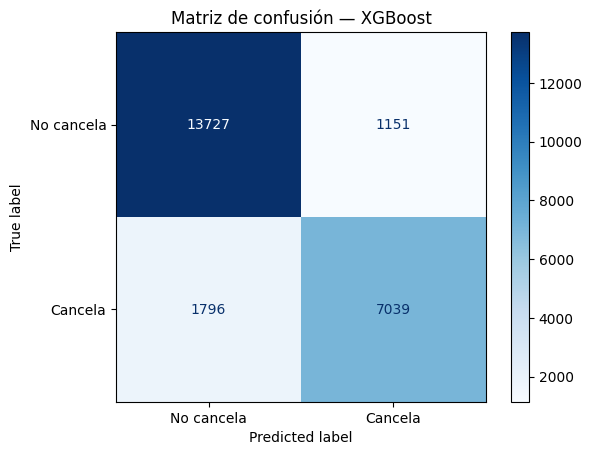

In [10]:
modelo_mejor = modelo_xgb
y_pred_mejor = modelo_mejor.predict(X_test)

cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — XGBoost')
plt.show()

La **curva ROC** enfrenta la tasa de verdaderos positivos (TPR) frente a la de falsos positivos (FPR) según el umbral; el **AUC** resume su calidad (0.5 = azar, 1 = perfecto).

In [11]:
y_proba_mejor = modelo_mejor.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_mejor)
auc = roc_auc_score(y_test, y_proba_mejor)

fig = px.area(
    x=fpr, y=tpr,
    title=f'ROC (AUC={auc:.4f})',
    labels=dict(x='Tasa de Falsos Positivos (FPR)', y='Tasa de Verdaderos Positivos (TPR)'),
    width=700, height=500,
)
fig.add_shape(type='line', line=dict(dash='dash', color='grey'), x0=0, x1=1, y0=0, y1=1)
fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show(renderer='notebook_connected')

## 5. Importancia de variables
Los modelos de árboles exponen `feature_importances_`: cuánto se apoya el modelo en cada columna. Mostramos las **20 más importantes** del XGBoost.

In [12]:
importancias = modelo_xgb.feature_importances_
df_importancias = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': importancias,
})
df_importancias = df_importancias.sort_values('importancia', ascending=False).head(20)
# Ordenamos ascendente para que el gráfico de barras horizontales quede de mayor a menor
df_importancias = df_importancias.sort_values('importancia', ascending=True)

fig = px.bar(
    df_importancias,
    x='importancia', y='variable',
    orientation='h', text_auto='.3f',
    title='Importancia de variables — XGBoost (Top 20)',
    labels={'importancia': 'Importancia', 'variable': 'Variable'},
    width=800, height=600,
)
fig.show(renderer='notebook_connected')

**Lectura.** Domina `deposit_type_Non Refund` (depósito no reembolsable, ~99 % de cancelación), seguido de `lead_time`, `country_*` y `market_segment_*` — coherente con lo que vimos en el EDA.

## 6. Optimización de hiperparámetros
Buscamos automáticamente buenas combinaciones por **validación cruzada**, optimizando el **ROC-AUC**. Mantenemos las búsquedas **pequeñas** para que el notebook corra en un tiempo razonable.

### 6.1 `GridSearchCV` sobre el Árbol de Decisión
Probamos **todas** las combinaciones de una rejilla pequeña (3×3) con validación cruzada de 3 *folds*.

In [13]:
dict_grid_tree = {
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [20, 50, 100],
}
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dict_grid_tree, scoring='roc_auc', cv=3, n_jobs=-1,
)
grid_tree.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {grid_tree.best_params_}')
print(f'Mejor ROC-AUC (CV):     {grid_tree.best_score_:.4f}\n')
res_tree_opt = evaluar(grid_tree.best_estimator_, X_test, y_test, 'Árbol (optimizado)')

Mejores hiperparámetros: {'max_depth': 16, 'min_samples_leaf': 20}
Mejor ROC-AUC (CV):     0.9170

── Árbol (optimizado) ──
  Accuracy:  0.8460
  Precisión: 0.8176
  Recall:    0.7551
  F1-Score:  0.7851
  ROC-AUC:   0.9229



### 6.2 `RandomizedSearchCV` sobre XGBoost
Como el espacio de XGBoost es grande, en vez de probarlo entero muestreamos **8 combinaciones al azar** (`n_iter=8`). Suele encontrar algo muy bueno con una fracción del coste de un *grid* completo.

In [14]:
dict_dist_xgb = {
    'n_estimators': [500, 600],
    'max_depth': [12, 14],
    'learning_rate': [0.03, 0.1, 0.2],
    'subsample': [0.8, 0.9],
}
rand_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=42),
    dict_dist_xgb, n_iter=8, scoring='roc_auc', cv=3, n_jobs=-1, random_state=42,
)
rand_xgb.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {rand_xgb.best_params_}')
print(f'Mejor ROC-AUC (CV):     {rand_xgb.best_score_:.4f}\n')
res_xgb_opt = evaluar(rand_xgb.best_estimator_, X_test, y_test, 'XGBoost (optimizado)')

Mejores hiperparámetros: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.1}
Mejor ROC-AUC (CV):     0.9492

── XGBoost (optimizado) ──
  Accuracy:  0.8892
  Precisión: 0.8694
  Recall:    0.8268
  F1-Score:  0.8476
  ROC-AUC:   0.9559



## 7. Conclusiones
- **XGBoost gana** con claridad: **ROC-AUC ≈ 0.95**, por delante de Random Forest, el Árbol de Decisión y la Regresión Logística.
- El ajuste de hiperparámetros (`GridSearchCV` / `RandomizedSearchCV`) exprime un poco más a cada modelo, pero **no cambia el ranking**.
- La señal predictiva vive sobre todo en las **categóricas** (`deposit_type = Non Refund` ≈ 99 % de cancelación) y en `lead_time`.

### ¿Cuándo preferir cada modelo?

| Modelo | Fuerte en | Cuándo elegirlo |
|---|---|---|
| **Regresión Logística** | Simplicidad, interpretabilidad, velocidad | Baseline rápido; cuando hace falta explicar coeficientes |
| **Árbol de Decisión** | Reglas legibles, sin escalado | Cuando prima **explicar** la decisión sobre maximizar el acierto |
| **Random Forest** | Robustez, poco *tuning*, buena precisión | Cuando se quiere un modelo sólido «out of the box» |
| **XGBoost** | **Máximo rendimiento** en datos tabulares | Cuando el objetivo es la **mejor predicción** (nuestro caso) |

Por eso el proyecto sirve **XGBoost** como modelo ganador.